In [89]:
import pandas as pd

df = pd.read_csv("/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/data/cleaned_data/cleaned_data.csv")
df.head()

,Job Title,Job Description,Rating,Company Name,Industry,Sector,mean_salary,company_age,size_category
0,senior data scientist,descriptionthe senior data scientist is respon...,3.1,healthfirst3.1,insurance carriers,insurance,154000.0,33.0,medium
1,data scientist,"secure our nation, ignite your futurejoin the ...",4.2,mantech4.2,research development,business services,154000.0,58.0,large
2,data scientist,overviewanalysis group is one of the largest i...,3.8,analysis group3.8,consulting,business services,154000.0,45.0,medium
3,data scientist,job descriptiondo you have a passion for data ...,3.5,inficon3.5,electrical electronic manufacturing,manufacturing,154000.0,26.0,medium
4,data scientist,data scientistaffinity solutions marketing cl...,2.9,affinity solutions2.9,advertising marketing,business services,154000.0,28.0,small


In [90]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["mean_salary"])
y = df["mean_salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= 42
)


In [91]:
# Colonnes numériques
num_features = ['company_age']

# Colonnes catégorielles (faible cardinalité)
cat_features = ['Industry', 'Sector', 'size_category']

# Colonnes texte (haute cardinalité / texte libre) → à encoder différemment
text_features = ['Job Title', 'Job Description', 'Company Name']

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numérique : imputer + scaler
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Catégoriel : imputer + OHE
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [93]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer 

# Texte : TF-IDF (pour Job Title surtout, Job Description optionnel) 
title_transformer = TfidfVectorizer(max_features=50, ngram_range=(1,2)) 
desc_transformer = TfidfVectorizer(max_features=100, stop_words='english') 
preprocessor = ColumnTransformer(transformers=[ 
    ('num', num_transformer, num_features), 
    ('cat', cat_transformer, cat_features), 
    ('title', title_transformer, 'Job Title'), 
    ('desc', desc_transformer, 'Job Description'), ],
    remainder='drop') # drop Company Name (trop de cardinalité)

In [94]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([ 
    ('preprocessor', preprocessor), 
    ('regressor', RandomForestRegressor(
        n_estimators=100,

        random_state=42)) ]) 
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [95]:
y_pred = model.predict(X_test)

In [96]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))

MAE : 28311.300837125837
R²  : -0.1920960557667284


In [97]:
import joblib

joblib.dump(model, "/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/model/hr_ai_platform.pkl")

['/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/model/hr_ai_platform.pkl']

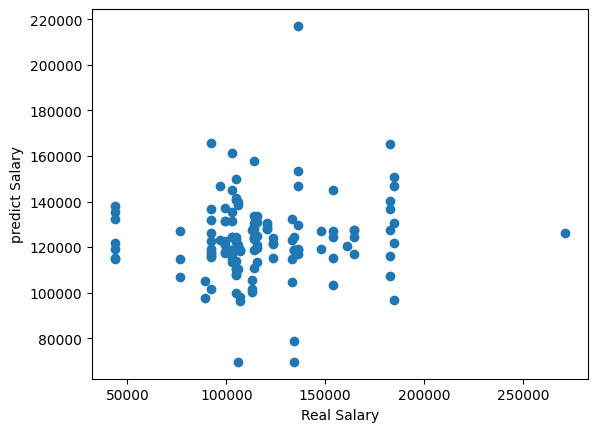

In [99]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Real Salary")
plt.ylabel("predict Salary")
plt.show()

In [101]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R²:", test_score)

Train R²: 0.6406733656327976
Test R²: -0.1920960557667284
